# a) DataFrame named df
## How many rows and columns are in the DataFrame df

In [1]:
import pandas as pd
df = pd.read_csv('measures.csv')
print(df.head)

# Get the number of rows and columns in the DataFrame
num_rows, num_columns = df.shape
print("Number of rows:", num_rows)
print("Number of columns:", num_columns)

<bound method NDFrame.head of                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

# d) Plot a histogram that displays the distribution of the class Diagnosis.

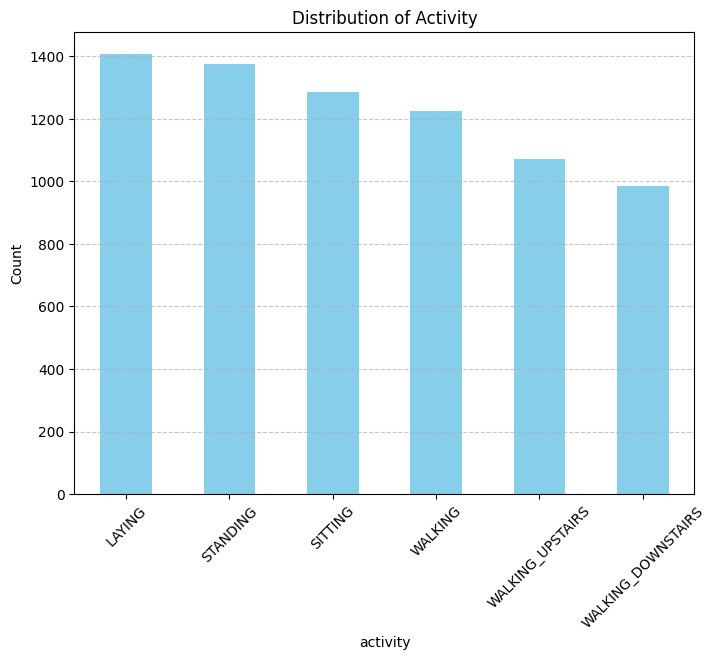

In [10]:
import matplotlib.pyplot as plt
# Plot histogram
plt.figure(figsize=(8,6))
df['activity'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Activity')
plt.xlabel('activity')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# e) Train a DecsisonTreeClassfier classifier with a maximum depth of three, using random state=42.

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('measures.csv', delimiter=';')
# Convert string numbers with commas to floats
for column in df.columns:
    if df[column].dtype == 'object':
        try:
            df[column] = df[column].str.replace(',', '.').astype(float)
        except ValueError:
            pass  # If conversion fails, it's probably a categorical column
X = df.drop(columns=['activity'])
y = df['activity']

# Split the data 0.7 train & 0.3 test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the DecisionTreeClassifier
dtree = DecisionTreeClassifier(max_depth=10, random_state=42)

# Train the classifier
dtree.fit(X_train, y_train)

# Obtain feature names and class names
feature_names = X.columns.tolist()
class_names = dtree.classes_.tolist()

# Display the text representation of the tree
from sklearn.tree import export_text
tree_text = export_text(dtree, feature_names=feature_names)
print(tree_text)

|--- tGravityAcc-min()-X <= 0.10
|   |--- class: LAYING
|--- tGravityAcc-min()-X >  0.10
|   |--- fBodyAcc-mad()-X <= -0.68
|   |   |--- angle(Y,gravityMean) <= 0.14
|   |   |   |--- tGravityAcc-mean()-X <= 0.94
|   |   |   |   |--- tBodyGyro-arCoeff()-Y,2 <= 0.68
|   |   |   |   |   |--- tBodyAccJerk-arCoeff()-Z,4 <= -0.88
|   |   |   |   |   |   |--- class: STANDING
|   |   |   |   |   |--- tBodyAccJerk-arCoeff()-Z,4 >  -0.88
|   |   |   |   |   |   |--- tBodyGyroJerk-correlation()-X,Y <= 0.71
|   |   |   |   |   |   |   |--- class: SITTING
|   |   |   |   |   |   |--- tBodyGyroJerk-correlation()-X,Y >  0.71
|   |   |   |   |   |   |   |--- tBodyAccJerk-correlation()-Y,Z <= 0.39
|   |   |   |   |   |   |   |   |--- class: SITTING
|   |   |   |   |   |   |   |--- tBodyAccJerk-correlation()-Y,Z >  0.39
|   |   |   |   |   |   |   |   |--- class: STANDING
|   |   |   |   |--- tBodyGyro-arCoeff()-Y,2 >  0.68
|   |   |   |   |   |--- class: STANDING
|   |   |   |--- tGravityAcc-mean()-X >

# f)Plot the tree as a graph.

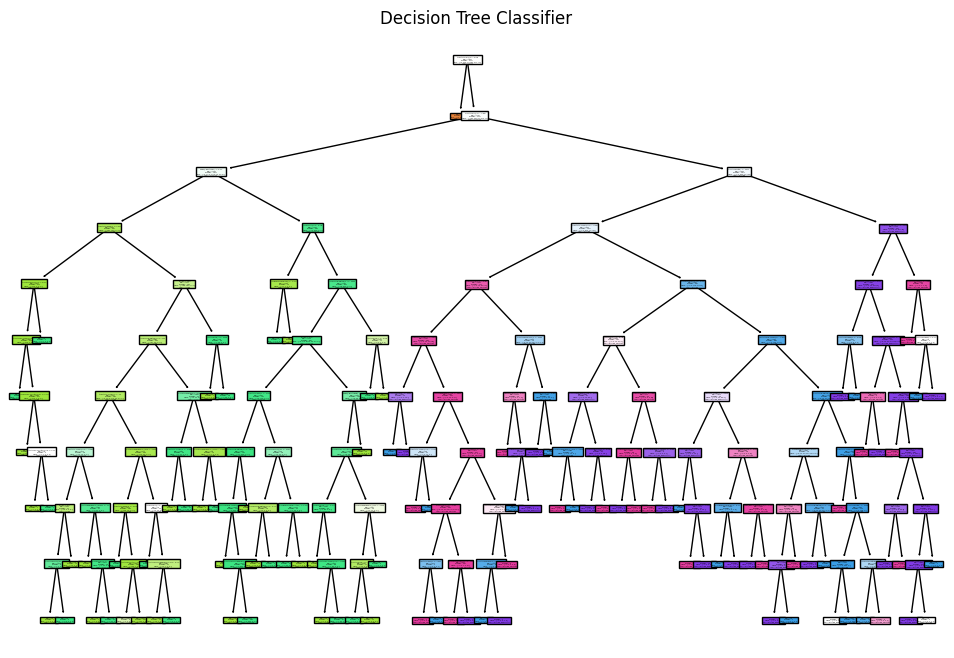

In [21]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot the decision tree as a graph
plt.figure(figsize=(12, 8))
plot_tree(dtree, feature_names=feature_names, class_names=class_names, filled=True)
plt.title("Decision Tree Classifier")
plt.show()


# g) Create a boxplot of the most important feature across different classes.

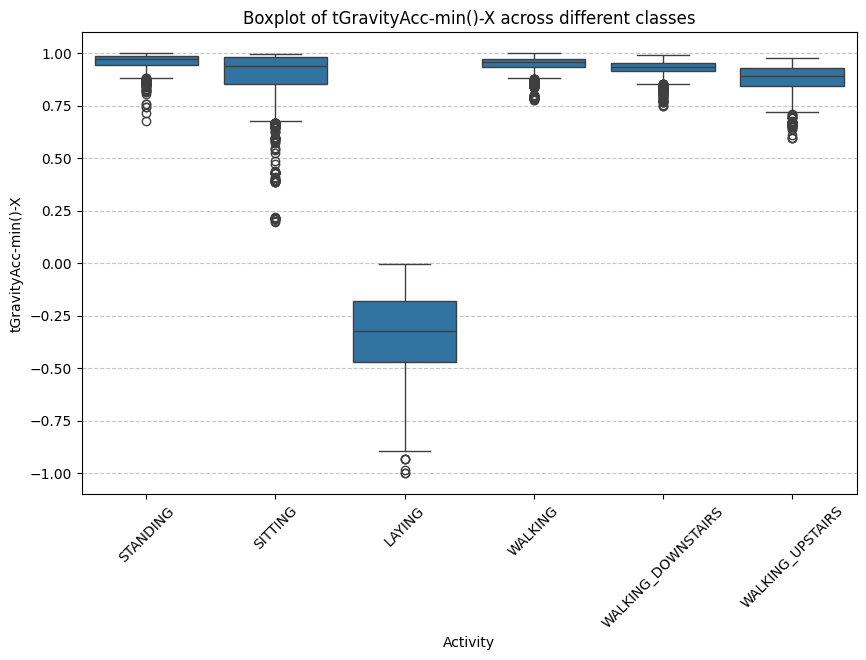

In [24]:
import seaborn as sns

# Identify the most important feature
most_important_feature_index = dtree.feature_importances_.argmax()
most_important_feature_name = feature_names[most_important_feature_index]

# Filter DataFrame to include only the most important feature and target variable
df_filtered = df[[most_important_feature_name, 'activity']]

# Create a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='activity', y=most_important_feature_name, data=df_filtered)
plt.title('Boxplot of {} across different classes'.format(most_important_feature_name))
plt.xlabel('Activity')
plt.ylabel(most_important_feature_name)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# •	On which features does the class strongly depend (correlation)?

In [31]:
# Which features are most important for the classifier?
feature_importances = dtree.feature_importances_

# Create a DataFrame to store the feature importances
df_importances = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})

# Sort the DataFrame in descending order of the feature importances
df_importances = df_importances.sort_values(by='importance', ascending=False)
print(df_importances[:10])

                         feature  importance
52           tGravityAcc-min()-X    0.237675
271             fBodyAcc-mad()-X    0.204277
559         angle(Y,gravityMean)    0.133171
201            tBodyAccMag-std()    0.110495
73     tGravityAcc-arCoeff()-Z,1    0.098342
448          fBodyGyro-maxInds-X    0.025325
159  tBodyGyro-correlation()-Y,Z    0.022416
57        tGravityAcc-energy()-Y    0.016652
561                      subject    0.012791
222    tGravityAccMag-arCoeff()1    0.011738


# •	Bivariate dependencies: Correlation matrix of features, strongest correlations, scatterplot of the most strongly correlated features

In [1]:
# Bivariate dependencies: Correlation matrix of features, strongest correlations, scatterplot of the most strongly correlated features
# Calculate the correlation matrix
correlation_matrix = X.corr()

# Find the strongest correlations
strongest_correlations = correlation_matrix.abs().unstack().sort_values(ascending=False)
strongest_correlations = strongest_correlations[strongest_correlations < 1]
print(strongest_correlations.head())

# Scatterplot of the most strongly correlated features
strongest_correlation = strongest_correlations.index[0]
feature1, feature2 = strongest_correlation
plt.figure(figsize=(10, 6))
sns.scatterplot(x=feature1, y=feature2, data=X)
plt.title('Scatterplot of the most strongly correlated features')
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

# Multivariate dependencies: Pairplot of the most important features
# Get the most important features
most_important_features = df_importances['feature'].head(4).tolist()

# Create a pairplot of the most important features
# making the pairplot colorful (colorfull classes to distinguish)
plt.figure(figsize=(12, 8))
sns.pairplot(df[most_important_features])
sns.pairplot(df[most_important_features], hue='activity', palette='Set2')
plt.suptitle('Pairplot of the most important features', y=1.02)
plt.show()

NameError: name 'X' is not defined

# Anomalies, most important influencing variables, coorelations between the features

In [ ]:
# Anomalies, most important influencing variables, coorelations between the features
# Identify the most important influencing variables of the predicted file
# file with no lables
# Load the data
df = pd.read_csv('../VSC_Preprocess_Models&Compare/my_prediction.csv', delimiter=';')

# Convert string numbers with commas to floats
for column in df.columns:
    if df[column].dtype == 'object':
        try:
            df[column] = df[column].str.replace(',', '.').astype(float)
        except ValueError:
            pass  # If conversion fails, it's probably a categorical column

# Predict the activity
df['activity'] = dtree.predict(df)

# Identify the most important influencing variables
most_important_influencing_variables = df_importances['feature'].head(4).tolist()
